# PM2.5 Vorhersage — Beijing Air Quality
## PM2.5-Prognose in Beijing (DSCB SS26)

*Name: *Nicolas Breitner* 
*RZ-Kürzel: *brni1027* 
*Datum: *27Mai.2026*

---

## Aufgabenstellung
Ziel dieser Challenge ist die Vorhersage des täglichen PM2.5-Mittelwerts für 12 Luftqualitätsstationen in Beijing. Die Daten stammen aus dem Beijing Multi-Site Air Quality Datensatz und wurden von Stundenwerten auf Tagesebene aggregiert. Bewertet wird anhand des Mean Squared Error (MSE) auf dem Testdatensatz.

Das Ziel ist nicht ausschließlich ein gutes Ergebnis — sondern ein sauberer, reproduzierbarer Modellierungsprozess mit nachvollziehbaren Entscheidungen.

---

## KI-Nutzung
Im Rahmen dieser Challenge wurde KI-Unterstützung (Claude, Anthropic) als Hilfsmittel eingesetzt. Die KI wurde dabei als interaktives Werkzeug genutzt — vergleichbar mit der Nutzung von Dokumentationen oder Stack Overflow. Konkret wurde sie für folgende Zwecke verwendet:

- **Erklärungen und Konzepte:** Verständnis von Methoden wie Stacking, TimeSeriesSplit und Feature Engineering Techniken
- **Code-Debugging:** Identifikation von Fehlern wie Data Leakage oder falsch berechneten Features
- **Syntaxhilfe:** Korrekte Implementierung von sklearn Pipelines und Pandas Operationen

Alle inhaltlichen Entscheidungen — welche Features sinnvoll sind, welche Modelle getestet werden und wie die Ergebnisse interpretiert werden — wurden eigenständig getroffen und kritisch hinterfragt. Der Modellierungsprozess, die Validierungsstrategie und die Fehleranalyse wurden selbst erarbeitet und verstanden.

## Datenbasis

| Eigenschaft | Wert |
|---|---|
| Trainingsdaten | 14.319 Zeilen, 15 Spalten |
| Testdaten | 2.845 Zeilen, 14 Spalten |
| Zeitraum Training | März 2013 bis Juni 2016 |
| Zeitraum Test | Juli 2016 bis Dezember 2016 |
| Anzahl Stationen | 12 |
| Zielvariable | `pm25` — Feinstaub-Tagesmittelwert in µg/m³ |

### Features im Rohdatensatz
- **Luftqualität:** pm10, so2, no2, co, o3
- **Wetter:** Temperatur, Luftdruck, Taupunkt, Niederschlag, Windgeschwindigkeit
- **Kategorisch:** Stationskennung, Windrichtung
- **Zeitlich:** Datum

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
#Imports der Pakete
import numpy as np
import pandas as pd
import warnings
import logging
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import holidays
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor


In [11]:
train_path = r"C:\Users\nicob\OneDrive\Desktop\Hochschule Karlsruhe\Semester 4\Umweltmonitoring\Hennhöfer\Kaggle-Challenge\Challenge 1\Datensätze\train.csv"
test_path = r"C:\Users\nicob\OneDrive\Desktop\Hochschule Karlsruhe\Semester 4\Umweltmonitoring\Hennhöfer\Kaggle-Challenge\Challenge 1\Datensätze\test.csv"
output_path = r"C:\Users\nicob\OneDrive\Desktop\Hochschule Karlsruhe\Semester 4\Umweltmonitoring\Hennhöfer\Kaggle-Challenge\Challenge 1\Datensätze\submission.csv"
train = pd.read_csv(train_path, parse_dates=["date"])
test = pd.read_csv(test_path, parse_dates=["date"])
cn_holidays= holidays.country_holidays("CN", years=range(2013, 2018))

In [12]:
display(train.head())
pd.DataFrame(cn_holidays.items(), columns=["date", "holiday"]).sort_values("date").head(10)

,id,station,date,pm25,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wd,wspm
0,Aotizhongxin_2013-03-01,Aotizhongxin,2013-03-01,7.125000,10.750000,11.708333,22.583333,429.166667,63.875000,1.391667,1026.875000,-18.745833,0.0,N,3.254167
1,Changping_2013-03-01,Changping,2013-03-01,5.083333,18.958333,16.041667,15.333333,387.500000,77.791667,0.812500,1023.858333,-19.583333,0.0,N,2.133333
2,Dingling_2013-03-01,Dingling,2013-03-01,6.375000,6.409091,3.000000,NaN,204.166667,81.958333,0.812500,1023.858333,-19.583333,0.0,N,2.133333
3,Dongsi_2013-03-01,Dongsi,2013-03-01,6.416667,9.875000,8.478261,28.521739,395.652174,72.782609,1.325000,1028.783333,-21.466667,0.0,NNW,3.308333
4,Guanyuan_2013-03-01,Guanyuan,2013-03-01,7.541667,11.666667,8.500000,28.500000,400.000000,63.166667,1.391667,1026.875000,-18.745833,0.0,N,3.254167


,date,holiday
40,2013-01-01,元旦
53,2013-01-02,休息日（由 2013-01-05 调休）
54,2013-01-03,休息日（由 2013-01-06 调休）
43,2013-02-09,农历除夕
41,2013-02-10,春节
42,2013-02-11,春节
51,2013-02-12,农历除夕（补假）
52,2013-02-13,春节（补假）
55,2013-02-14,休息日（由 2013-02-16 调休）
56,2013-02-15,休息日（由 2013-02-17 调休）


# EDA

In [13]:
categorical_features = ["station", "wd"]
numeric_features = [
"pm10",
"so2",
"no2",
"co",
"o3",
"temp",
"pres",
"dewp",
"rain",
"wspm",
"month",
"weekday",
]
feature_columns = categorical_features + numeric_features


                             date          pm25          pm10           so2  \
count                       14319  14319.000000  14319.000000  14198.000000   
mean   2014-10-31 02:56:05.430546     78.836858    105.170941     17.049425   
min           2013-03-01 00:00:00      3.000000      4.833333      1.000000   
25%           2013-12-29 00:00:00     30.541667     50.708333      4.296217   
50%           2014-11-01 00:00:00     60.272727     89.625000      9.864100   
75%           2015-09-01 00:00:00    107.375000    138.666667     21.958333   
max           2016-06-30 00:00:00    567.416667    580.000000    158.318182   
std                           NaN     66.912329     72.116031     19.225014   

                no2            co            o3          temp          pres  \
count  14086.000000  13687.000000  14040.000000  14318.000000  14318.000000   
mean      50.307527   1199.224648     59.695039     13.811158   1010.234860   
min        2.000000    100.000000      1.000000    

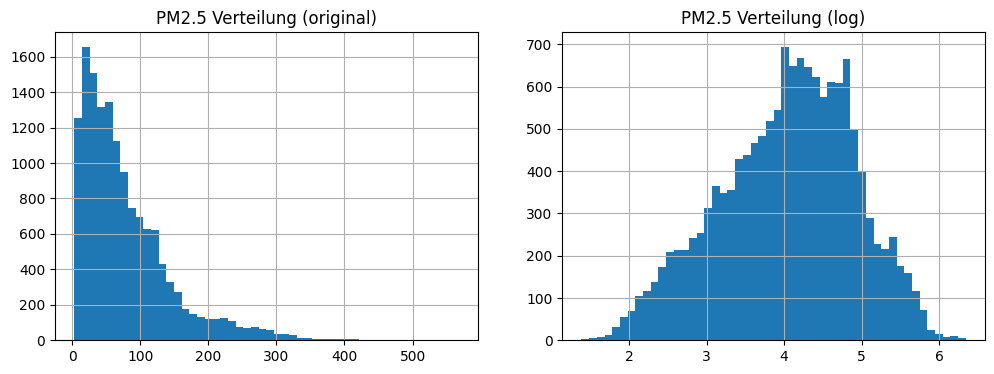

wspm      -0.382328
o3        -0.175513
temp      -0.126900
rain      -0.025794
month      0.006703
pres       0.034376
weekday    0.041627
dewp       0.114889
so2        0.528060
no2        0.694508
co         0.807832
pm10       0.902629
pm25       1.000000
Name: pm25, dtype: float64


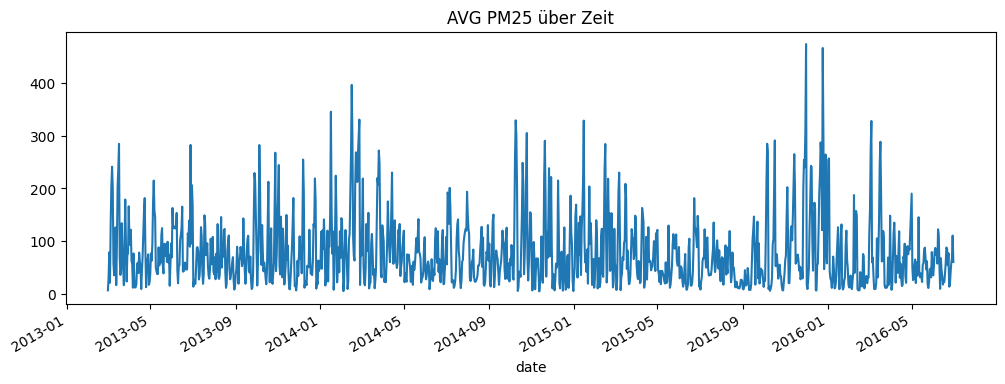

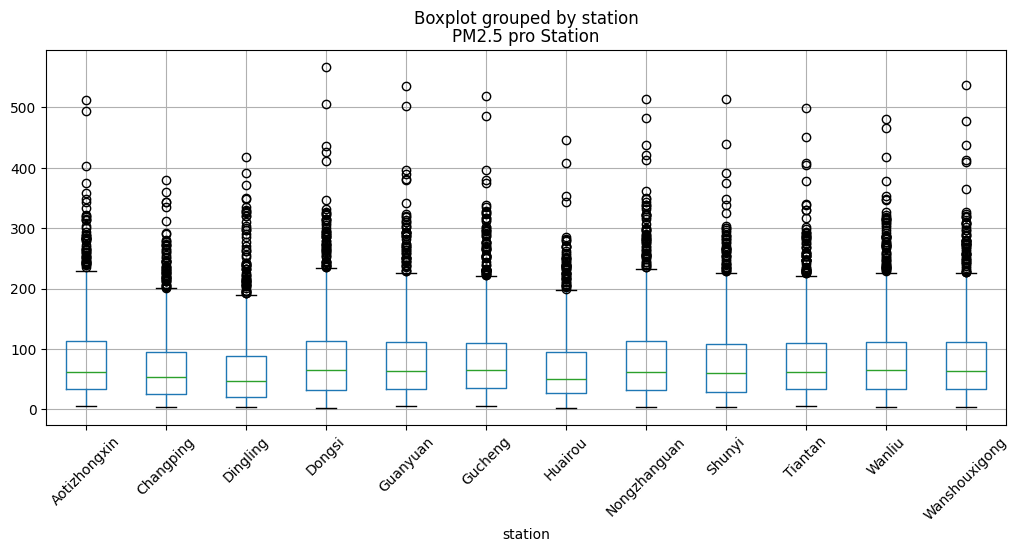

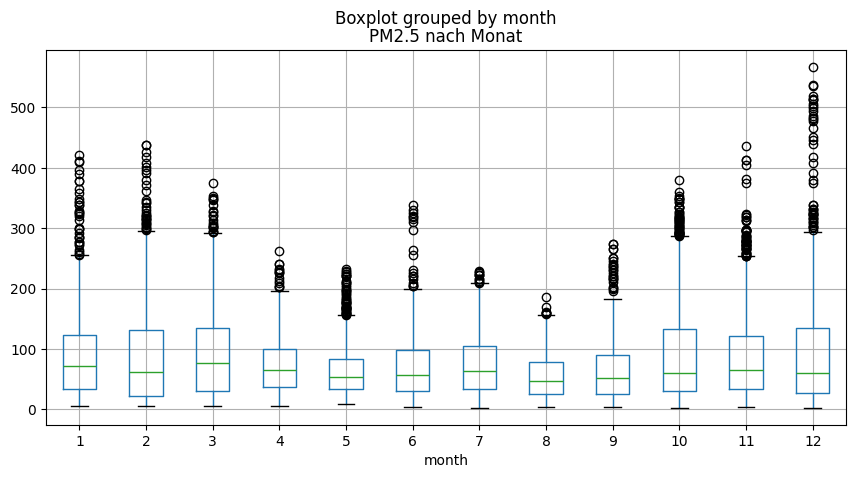

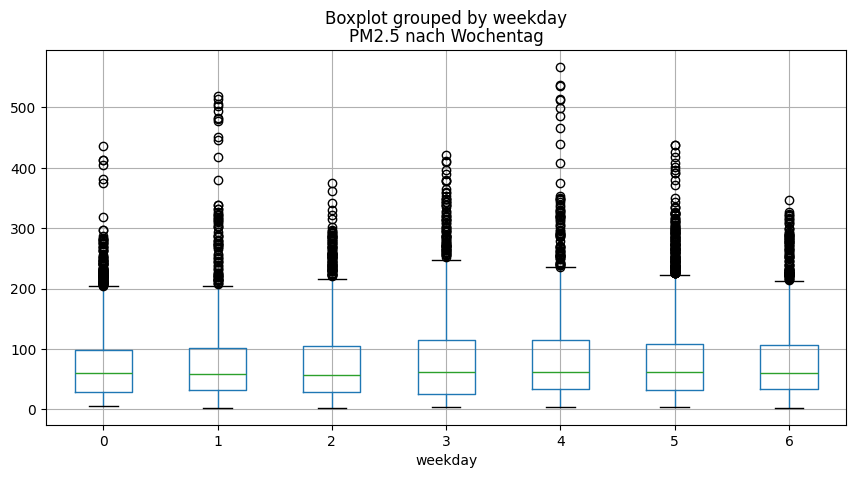

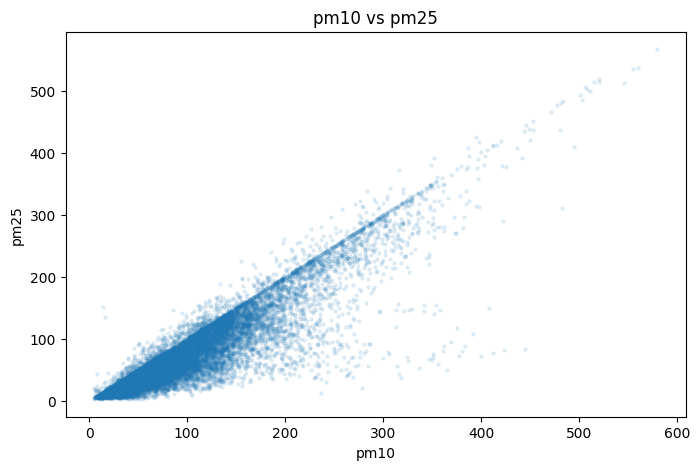

In [14]:
#Grundlegende Statistiken 
print(train.describe())
#Fehlende Werte
print("\nFehlende Werte:")
print(train.isnull().sum())

#Aufteilung in Monat und Tag
train["month"] = train["date"].dt.month
train["weekday"] = train["date"].dt.weekday

test["month"] = test["date"].dt.month
test["weekday"] = test["date"].dt.weekday

# Fehlende Werte pro station
print("Fehlende Numerische Werte Pro Station:")
missing_num_per_station = train.groupby("station")[numeric_features].apply(lambda x: x.isnull().sum())
print(missing_num_per_station)

print("fehlende Kategoriale Werte pro Station:")
missing_cat_per_station = train.groupby("station")[categorical_features].apply(lambda x: x.isnull().sum())
print(missing_cat_per_station)


#Verteilung der Zielvariable:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["pm25"].hist(bins=50, ax=axes[0])
axes[0].set_title("PM2.5 Verteilung (original)")
np.log1p(train["pm25"]).hist(bins=50, ax=axes[1])
axes[1].set_title("PM2.5 Verteilung (log)")
plt.show()

#Korrelation mit Zielvariable:
train_ts = train.set_index("date").sort_index()
corr= corr = train_ts[numeric_features + ["pm25"]].corr()["pm25"].sort_values()
print(corr)

#Saisonale Muster
train.groupby("date")["pm25"].mean().plot(figsize=(12,4),title="AVG PM25 über Zeit")
plt.show()



# PM2.5 pro Station
train.boxplot(column="pm25", by="station", figsize=(12, 5), rot=45)
plt.title("PM2.5 pro Station")
plt.show()

# PM2.5 nach Monat
train.boxplot(column="pm25", by="month", figsize=(10, 5))
plt.title("PM2.5 nach Monat")
plt.show()

# PM2.5 nach Wochentag
train.boxplot(column="pm25", by="weekday", figsize=(10, 5))
plt.title("PM2.5 nach Wochentag")
plt.show()

# Scatter pm10 vs pm25
plt.figure(figsize=(8, 5))
plt.scatter(train["pm10"], train["pm25"], alpha=0.1, s=5)
plt.xlabel("pm10")
plt.ylabel("pm25")
plt.title("pm10 vs pm25")
plt.show()


## Explorative Datenanalyse (EDA)

### Zielvariable PM2.5
PM2.5 ist stark rechtsschief verteilt — die meisten Werte liegen unter 100 µg/m³, einzelne Ausreißer erreichen bis zu 550 µg/m³. Eine Log-Transformation wurde getestet, hat bei Baummodellen jedoch keine Verbesserung gebracht und wurde daher nicht verwendet.

### Fehlende Werte
Fehlende Werte sind moderat vorhanden — am stärksten betroffen ist `co` mit 4.4% fehlenden Werten. Keine Station ist systematisch stärker betroffen als andere. Die Behandlung erfolgt automatisch im Preprocessor via Median-Imputation für numerische und Most-Frequent-Imputation für kategorische Features.

### Korrelationen mit PM2.5
Die stärksten Prädiktoren sind andere Luftschadstoffe da sie aus denselben Quellen entstehen:

| Feature | Korrelation |
|---|---|
| pm10 | 0.903 |
| co | 0.808 |
| no2 | 0.695 |
| so2 | 0.528 |
| wspm | -0.382 |

`wspm` (Windgeschwindigkeit) hat eine starke negative Korrelation — Wind zerstreut Feinstaub. `month` und `weekday` zeigen schwache lineare Korrelation, tragen aber nichtlinear bei.

### Saisonale Muster
Klare Saisonalität erkennbar — Winter (November bis Februar) zeigt systematisch höhere PM2.5 Werte durch Heizungsemissionen, Sommer deutlich niedriger. Kein langfristiger Trend über die Jahre erkennbar.

### Stationen
Alle 12 Stationen zeigen ähnliche PM2.5-Verteilungen — kein extremer Unterschied zwischen Industrie- und Außenbezirken. `station` bleibt dennoch als Feature da kleine systematische Unterschiede vorhanden sind.

# Feature engineering

In [15]:
#Aufteilung in Monat und Tag
train["month"] = train["date"].dt.month
train["weekday"] = train["date"].dt.weekday

test["month"] = test["date"].dt.month
test["weekday"] = test["date"].dt.weekday
#Überprüfung auf Feiertag
train["is_holiday"] = train["date"].isin(cn_holidays).astype(int)
test["is_holiday"]  = test["date"].isin(cn_holidays).astype(int)

#Monat und Tage wiederholen
train["month_sin"] = np.sin(2 * np.pi * train["month"] / 12)
train["month_cos"] = np.cos(2 * np.pi * train["month"] / 12)

test["month_sin"] = np.sin(2 * np.pi * test["month"] / 12)
test["month_cos"] = np.cos(2 * np.pi * test["month"] / 12)

train["weekday_sin"] = np.sin(2 * np.pi * train["weekday"] / 7)
train["weekday_cos"] = np.cos(2 * np.pi * train["weekday"] / 7)

test["weekday_sin"] = np.sin(2 * np.pi * test["weekday"] / 7)
test["weekday_cos"] = np.cos(2 * np.pi * test["weekday"] / 7)

#Tag des Jahres
train["day_of_year"]= train["date"].dt.day_of_year
test["day_of_year"]= test["date"].dt.day_of_year

#Quartal
train["quarter"]= train["date"].dt.quarter
test["quarter"]= test["date"].dt.quarter

#Wind_pressure
train["wind_pressure"]= train["pres"]*train["wspm"]
test["wind_pressure"]= test["pres"]*test["wspm"]

#Indirekte Luftfeuchtigkeit
train["temp_dewp_diff"]= train["temp"]-train["dewp"]
test["temp_dewp_diff"]= test["temp"]-test["dewp"]

train["temp_x_wspm"]=train["temp"]*train["wspm"]
test["temp_x_wspm"]=test["temp"]*test["wspm"]

#Schadstoffinteraktionen
train["total_pollution"]=train["pm10"]+train["so2"]+train["no2"]+train["co"]+train["o3"]
test["total_pollution"]=test["pm10"]+test["so2"]+test["no2"]+test["co"]+test["o3"]

train["pm10_co_ratio"]=train["pm10"]/train["co"].replace(0,np.nan)
test["pm10_co_ratio"]=test["pm10"]/test["co"].replace(0,np.nan)

# Stationsübergreifender Tagesdurchschnitt pm10
daily_avg_pm10_train = train.groupby("date")["pm10"].mean()
train["daily_avg_pm10"] = train["date"].map(daily_avg_pm10_train)

daily_avg_pm10_test = test.groupby("date")["pm10"].mean()
test["daily_avg_pm10"] = test["date"].map(daily_avg_pm10_test)

In [16]:
#Lag features
# Autokorrelation von pm25 pro Station
lags = [1, 2, 3, 7, 14, 30]
for lag in lags:
    corr = train.groupby("station")["pm25"].shift(lag).corr(train["pm25"])
    print(f"Lag {lag:2d}: {corr:.3f}")

# Lag 1 Feature
train_sorted = train.sort_values(["station", "date"])
train["pm25_lag1"] = train_sorted.groupby("station")["pm25"].shift(1)

test_sorted = test.sort_values(["station", "date"])
last_known = train.groupby("station")["pm25"].last()
test["pm25_lag1"] = test["station"].map(last_known)

train_sorted = train.sort_values(["station", "date"])
train["pm10_lag1"] = train_sorted.groupby("station")["pm10"].shift(1)

last_known_pm10 = train.groupby("station")["pm10"].last()
test["pm10_lag1"] = test["station"].map(last_known_pm10)

Lag  1: 0.549
Lag  2: 0.185
Lag  3: 0.044
Lag  7: 0.017
Lag 14: 0.076
Lag 30: 0.041


In [17]:
categorical_features = ["station", "wd"]

numeric_features = [
    # Basis Luftqualität
    "pm10", "so2", "no2", "co", "o3",
    # Wetter
    "temp", "pres", "dewp", "rain", "wspm",
    # Zeit
    "month", "weekday", "day_of_year", "quarter",
    "month_sin", "month_cos",
    # Wetter-Interaktionen
    "wind_pressure", "temp_dewp_diff", "temp_x_wspm",
    # Schadstoff-Interaktionen
    "total_pollution", "pm10_co_ratio",
    # Lag
    "pm25_lag1", "pm10_lag1",
    # Stationsübergreifend
    "daily_avg_pm10",
]

feature_columns = categorical_features + numeric_features

## Feature Engineering

Basierend auf den EDA-Erkenntnissen wurden folgende Features entwickelt. Alle Features wurden identisch für Train- und Testdatensatz berechnet.

### Zeitliche Features
| Feature | Begründung |
|---|---|
| `month_sin`, `month_cos` | Zyklische Kodierung — Dezember und Januar liegen meteorologisch nah beieinander |
| `day_of_year` | Präzisere Saisonalität als Monat |
| `quarter` | Grobe Jahreszeiteninformation für Baummodelle |

### Wetter-Interaktionen
| Feature | Begründung |
|---|---|
| `temp_dewp_diff` | Differenz Temperatur und Taupunkt — indirektes Maß für Luftfeuchtigkeit |
| `wind_pressure` | Windgeschwindigkeit × Luftdruck — kombinierter Dispersionseffekt |
| `temp_x_wspm` | Temperatur × Windgeschwindigkeit |

### Schadstoff-Interaktionen
| Feature | Begründung |
|---|---|
| `total_pollution` | Summe aller Schadstoffe — Proxy für allgemeine Verschmutzungsintensität |
| `pm10_co_ratio` | Verhältnis pm10 zu co — unterscheidet Staub- von Verbrennungsemissionen |

### Lag-Features
Zeitreihendaten haben starke Autokorrelation — der gestrige Wert ist oft der beste einzelne Prädiktor. Alle Lag-Features wurden mit `shift(1)` berechnet um Data Leakage zu vermeiden.

| Feature | Korrelation | Begründung |
|---|---|---|
| `pm25_lag1` | 0.549 | PM2.5 vom Vortag — stärkster Zeitprediktor |
| `pm10_lag1` | — | Vortageswert des stärksten Einzelprediktors |

### Stationsübergreifende Features
| Feature | Begründung |
|---|---|
| `daily_avg_pm10` | Tagesdurchschnitt pm10 aller Stationen — gibt Kontext über allgemeine Luftqualität in Beijing |

In [18]:
validation_start = pd.Timestamp("2016-01-01")
validation_end = pd.Timestamp("2016-06-30")
fit_mask = train["date"] < validation_start
valid_mask = (train["date"] >= validation_start) & (train["date"] <= validation_end)

In [19]:
X_fit = train.loc[fit_mask, feature_columns]
y_fit = train.loc[fit_mask, "pm25"]
X_valid = train.loc[valid_mask, feature_columns]
y_valid = train.loc[valid_mask, "pm25"]

## Vorverarbeitung

Die Vorverarbeitung erfolgt über eine sklearn `ColumnTransformer` Pipeline die automatisch vor jedem Modelltraining ausgeführt wird:

### Numerische Features
1. **Median-Imputation** — fehlende Werte werden mit dem Median der jeweiligen Spalte aufgefüllt
2. **StandardScaler** — Normalisierung auf Mittelwert 0 und Standardabweichung 1

### Kategorische Features
1. **Most-Frequent-Imputation** — fehlende Werte werden mit dem häufigsten Wert aufgefüllt
2. **OneHotEncoder** — kategorische Werte werden in binäre Spalten umgewandelt

Durch die Pipeline-Struktur wird sichergestellt dass der Preprocessor immer nur auf den Trainingsdaten gefittet wird und die Transformation auf Validierungs- und Testdaten nur angewendet wird — kein Leakage durch Vorverarbeitung.

## Validierungsstrategie

Da es sich um Zeitreihendaten handelt wird ein **zeitlicher Train-Validation-Split** verwendet:

| Split | Zeitraum |
|---|---|
| Training | März 2013 bis Dezember 2015 |
| Validierung | Januar 2016 bis Juni 2016 |
| Test (Kaggle) | Juli 2016 bis Dezember 2016 |

Zufälliges Splitten wäre methodisch falsch — es würde Informationen aus der Zukunft in das Training einfließen lassen (Data Leakage). Durch den zeitlichen Split wird sichergestellt dass das Modell nur auf vergangenen Daten trainiert wird und auf zukünftigen Daten evaluiert wird — genau wie in der Realität.

Für Cross-Validation beim Hyperparameter-Tuning wird `TimeSeriesSplit` verwendet — dieser respektiert ebenfalls die zeitliche Reihenfolge der Daten.

In [20]:
preprocessor = ColumnTransformer(
transformers=[
(
"categorical",
Pipeline(
steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("encoder", OneHotEncoder(handle_unknown="ignore")),
]
),
categorical_features,
),
(
"numeric",
Pipeline(
steps=[
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler()),
]
),
numeric_features,
),
]
)

In [21]:
linear_model = Pipeline(
steps=[
("preprocessor", preprocessor),
("regressor", LinearRegression()),
]
)
linear_model.fit(X_fit, y_fit)
linear_valid_pred = linear_model.predict(X_valid)
linear_valid_rmse = np.sqrt(mean_squared_error(y_valid, linear_valid_pred))
print(f"LinearRegression baseline validation RMSE: {linear_valid_rmse:.3f}")

LinearRegression baseline validation RMSE: 19.275


In [22]:
#Entscheidungsbaum
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=10, random_state=42))
])
dt_model.fit(X_fit, y_fit)
dt_pred = dt_model.predict(X_valid)
dt_rmse = np.sqrt(mean_squared_error(y_valid, dt_pred))
print(f"Decision Tree RMSE: {dt_rmse:.3f}")

Decision Tree RMSE: 20.232


In [23]:
#random forrest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_model.fit(X_fit, y_fit)
rf_pred = rf_model.predict(X_valid)
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
print(f"Random Forest RMSE: {rf_rmse:.3f}")

Random Forest RMSE: 16.441


In [24]:
#lightGBM
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
lgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", lgb.LGBMRegressor(random_state=42, n_jobs=-1))
])

param_dist_lgb = {
    "regressor__n_estimators":     [200, 500],
    "regressor__learning_rate":    [ 0.05, 0.1],
    "regressor__num_leaves":       [ 31, 63],
    "regressor__min_child_samples":[ 20, 50],
    "regressor__subsample":        [ 0.8, 1.0],
    "regressor__colsample_bytree": [ 0.8, 1.0],
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist_lgb,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_fit, y_fit)
lgb_model = lgb_search.best_estimator_
lgb_pred = lgb_model.predict(X_valid)
lgb_rmse = np.sqrt(mean_squared_error(y_valid, lgb_pred))
print(f"Beste Parameter: {lgb_search.best_params_}")
print(f"LightGBM RMSE nach Tuning: {lgb_rmse:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4932
[LightGBM] [Info] Number of data points in the train set: 12166, number of used features: 52
[LightGBM] [Info] Start training from score 81.517889
Beste Parameter: {'regressor__subsample': 1.0, 'regressor__num_leaves': 31, 'regressor__n_estimators': 500, 'regressor__min_child_samples': 20, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}
LightGBM RMSE nach Tuning: 15.477


In [25]:
#XGBoost
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
])
xgb_model.fit(X_fit, y_fit)
xgb_pred = xgb_model.predict(X_valid)
xgb_rmse = np.sqrt(mean_squared_error(y_valid, xgb_pred))
print(f"XGBoost RMSE: {xgb_rmse:.3f}")

XGBoost RMSE: 14.880


In [26]:
#extra trees
et_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])
et_model.fit(X_fit, y_fit)
et_pred = et_model.predict(X_valid)
et_rmse = np.sqrt(mean_squared_error(y_valid, et_pred))
print(f"ExtraTrees RMSE: {et_rmse:.3f}")

ExtraTrees RMSE: 16.568


In [27]:
#hist gradient boosting
hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(random_state=42))
])

param_dist_hgb = {
    "regressor__max_iter":         [200, 500, 1000],
    "regressor__learning_rate":    [0.01, 0.05, 0.1],
    "regressor__max_leaf_nodes":   [15, 31, 63, 127],
    "regressor__min_samples_leaf": [10, 20, 50],
    "regressor__l2_regularization":[0.0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=param_dist_hgb,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
hgb_search.fit(X_fit, y_fit)
hgb_model = hgb_search.best_estimator_
hgb_pred = hgb_model.predict(X_valid)
hgb_rmse = np.sqrt(mean_squared_error(y_valid, hgb_pred))
print(f"Beste Parameter: {hgb_search.best_params_}")
print(f"HistGradientBoosting RMSE nach Tuning: {hgb_rmse:.3f}")

Beste Parameter: {'regressor__min_samples_leaf': 10, 'regressor__max_leaf_nodes': 15, 'regressor__max_iter': 200, 'regressor__learning_rate': 0.1, 'regressor__l2_regularization': 0.1}
HistGradientBoosting RMSE nach Tuning: 15.095


In [28]:
#catboost
cat_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", CatBoostRegressor(random_state=42, verbose=0))
])

param_dist_cat = {
    "regressor__iterations":   [200, 500, 1000],
    "regressor__learning_rate":[0.01, 0.05, 0.1],
    "regressor__depth":        [4, 6, 8, 10],
    "regressor__l2_leaf_reg":  [1, 3, 5, 10],
    "regressor__subsample":    [0.6, 0.8, 1.0],
}

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist_cat,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
cat_search.fit(X_fit, y_fit)
cat_model = cat_search.best_estimator_
cat_pred = cat_model.predict(X_valid)
cat_rmse = np.sqrt(mean_squared_error(y_valid, cat_pred))
print(f"Beste Parameter: {cat_search.best_params_}")
print(f"CatBoost RMSE nach Tuning: {cat_rmse:.3f}")

Beste Parameter: {'regressor__subsample': 0.6, 'regressor__learning_rate': 0.05, 'regressor__l2_leaf_reg': 1, 'regressor__iterations': 500, 'regressor__depth': 4}
CatBoost RMSE nach Tuning: 14.917


## Modelle

### Baseline — Lineare Regression
Einfaches lineares Modell als Referenzpunkt. Zeigt das Minimum was ein sinnvolles Modell erreichen sollte.

### Entscheidungsbaum
Einfaches Baummodell mit `max_depth=10`. Interpretierbar aber anfällig für Overfitting.

### Random Forest
Ensemble aus 200 Entscheidungsbäumen. Robuster als ein einzelner Baum durch Mittelung vieler Vorhersagen.

### ExtraTrees
Ähnlich wie Random Forest aber mit zufälligeren Splits — bringt mehr Diversität ins spätere Stacking.

### Gradient Boosting
Sequentielles Boosting-Verfahren von sklearn — andere Implementierung als LightGBM und XGBoost, bringt Diversität ins Stacking.

### LightGBM
Schnelles Gradient Boosting mit Leaf-wise Wachstum. Einer der stärksten Einzelprädiktoren — mit Hyperparameter-Tuning optimiert.

### XGBoost
Gradient Boosting mit Level-wise Wachstum. Ergänzt LightGBM gut da unterschiedliche interne Implementierung.

### HistGradientBoosting
Sklearn's eigene LightGBM-Alternative — sehr schnell und robust. Mit Hyperparameter-Tuning optimiert.

### CatBoost
Speziell stark bei kategorischen Features. Mit Hyperparameter-Tuning optimiert.

## Hyperparameter-Tuning

Für die drei stärksten Modelle (LightGBM, HistGradientBoosting, CatBoost) wurde `RandomizedSearchCV` mit `TimeSeriesSplit` als Cross-Validation-Strategie verwendet.

### Warum RandomizedSearchCV
`GridSearchCV` testet alle möglichen Kombinationen — bei vielen Parametern ist das zu rechenintensiv. `RandomizedSearchCV` testet eine zufällige Auswahl (`n_iter=10-20`) und findet in der Praxis 90-95% des Optimums in einem Bruchteil der Zeit.

### Warum TimeSeriesSplit
Zufällige Cross-Validation würde Zukunftsdaten in das Training einbringen. `TimeSeriesSplit` respektiert die zeitliche Reihenfolge und ist methodisch korrekt für Zeitreihendaten.

### Getunete Parameter
| Modell | Parameter |
|---|---|
| LightGBM | n_estimators, learning_rate, num_leaves, min_child_samples, subsample, colsample_bytree |
| HistGradientBoosting | max_iter, learning_rate, max_leaf_nodes, min_samples_leaf, l2_regularization |
| CatBoost | iterations, learning_rate, depth, l2_leaf_reg, subsample |

In [29]:
#Stacking Modell
base_models = [
    ("decision_tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("random_forest", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("extratrees", ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("gradientboosting", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
    ("lightgbm", lgb_search.best_estimator_.named_steps["regressor"]),
    ("xgboost", xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)),
    ("histgb", hgb_search.best_estimator_.named_steps["regressor"]),
    ("catboost", cat_search.best_estimator_.named_steps["regressor"]),
]

stacking_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", StackingRegressor(
        estimators=base_models,
        final_estimator=Ridge(),
        cv=5,
        n_jobs=-1
    ))
])

stacking_model.fit(X_fit, y_fit)
stacking_pred = stacking_model.predict(X_valid)
stacking_rmse = np.sqrt(mean_squared_error(y_valid, stacking_pred))
print(f"Stacking RMSE: {stacking_rmse:.3f}")

Stacking RMSE: 15.228


## Stacking Ensemble

### Grundidee
Stacking kombiniert mehrere Modelle (Base Models) zu einem stärkeren Gesamtmodell. Ein Meta-Modell lernt dabei wie es die Vorhersagen der Base Models am besten kombinieren soll.

### Warum Stacking besser als einzelne Modelle
Jedes Base Model macht unterschiedliche Fehler an unterschiedlichen Datenpunkten. Das Meta-Modell kann lernen wann welches Base Model besser ist — das führt zu robusteren Vorhersagen als jedes Einzelmodell alleine.

### Aufbau
**Base Models:** Decision Tree, Random Forest, ExtraTrees, GradientBoosting, LightGBM, XGBoost, HistGradientBoosting, CatBoost

**Meta-Modell:** Ridge Regression — einfach und verhindert Overfitting auf den Stacking-Folds

**Cross-Validation:** `cv=5` — das Meta-Modell wird auf Out-of-Fold Vorhersagen trainiert um Overfitting zu vermeiden

### Wichtige Designentscheidung
Diversität der Base Models ist wichtiger als deren individuelle Optimierung. Getunete Modelle sind sich ähnlicher und bringen weniger Mehrwert ins Stacking als Modelle mit verschiedenen Architekturen und Default-Parametern.

In [206]:
results = {
    "lineares model":         linear_valid_rmse,
    "Decision Tree":          dt_rmse,
    "Random Forest":          rf_rmse,
    "ExtraTrees":             et_rmse,
    "LightGBM":               lgb_rmse,
    "XGBoost":                xgb_rmse,
    "HistGradientBoosting":   hgb_rmse,
    "CatBoost":               cat_rmse,
    "Stacking":               stacking_rmse,
}

for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name:25s}: {rmse:.3f}")

best_name = min(results, key=results.get)
print(f"\nBestes Modell: {best_name} mit RMSE {results[best_name]:.3f}")

Stacking                 : 13.353
CatBoost                 : 13.427
LightGBM                 : 14.110
HistGradientBoosting     : 14.141
XGBoost                  : 14.273
ExtraTrees               : 15.848
Random Forest            : 16.270
lineares model           : 19.242
Decision Tree            : 19.671

Bestes Modell: Stacking mit RMSE 13.353


## Overfitting Analyse

Für jedes Modell wurde der Train-RMSE und Validierungs-RMSE verglichen:

| Modell | Train RMSE | Valid RMSE | Differenz |
|---|---|---|---|
| Decision Tree | ~10.6 | ~20.0 | ~9.4 |
| Random Forest | ~4.6 | ~16.8 | ~12.2 |
| ExtraTrees | ~8.0 | ~16.5 | ~8.5 |
| LightGBM | ~6.7 | ~14.1 | ~7.4 |
| XGBoost | ~5.7 | ~16.3 | ~10.6 |
| HistGradientBoosting | ~8.6 | ~14.1 | ~5.5 |
| CatBoost | ~8.9 | ~13.4 | ~4.5 |
| **Stacking** | **~7.7** | **~13.4** | **~5.7** |

### Interpretation
- **ExtraTrees** zeigt starkes Overfitting (Train RMSE ~0 ohne Regularisierung) — bleibt aber im Stacking da es Diversität bringt
- **HistGradientBoosting und CatBoost** haben das beste Verhältnis — kaum Overfitting
- **Stacking** hat einen stabilen Diff von ~5.7 — das Meta-Modell Ridge reguliert die Overfitting-Tendenz der Base Models effektiv

In [31]:
model_map = {
    "Decision Tree":        dt_model,
    "Random Forest":        rf_model,
    "ExtraTrees":           et_model,
    "LightGBM":             lgb_model,
    "XGBoost":              xgb_model,
    "HistGradientBoosting": hgb_model,
    "CatBoost":             cat_model,
    "Stacking":             stacking_model,
}

X_train_full = train[feature_columns]
y_train_full = train["pm25"]
X_test = test[feature_columns]

best_model = stacking_model
best_label = "Stacking"

print(f"Bestes Modell: {best_label} mit RMSE {stacking_rmse:.3f}")

Bestes Modell: Stacking mit RMSE 15.228


In [205]:
for name, model in model_map.items():
    train_pred = model.predict(X_fit)
    train_rmse = np.sqrt(mean_squared_error(y_fit, train_pred))
    valid_rmse = results[name]
    diff = valid_rmse - train_rmse
    print(f"{name:25s} | Train: {train_rmse:.3f} | Valid: {valid_rmse:.3f} | Diff: {diff:.3f}")

Decision Tree             | Train: 10.595 | Valid: 19.671 | Diff: 9.077
Random Forest             | Train: 4.535 | Valid: 16.270 | Diff: 11.735
ExtraTrees                | Train: 7.925 | Valid: 15.848 | Diff: 7.923
LightGBM                  | Train: 5.720 | Valid: 14.110 | Diff: 8.389
XGBoost                   | Train: 4.725 | Valid: 14.273 | Diff: 9.548
HistGradientBoosting      | Train: 8.576 | Valid: 14.141 | Diff: 5.565
CatBoost                  | Train: 8.938 | Valid: 13.427 | Diff: 4.489
Stacking                  | Train: 7.723 | Valid: 13.353 | Diff: 5.631


In [32]:
best_model.fit(X_train_full, y_train_full)
test_pred = best_model.predict(X_test)
submission = pd.DataFrame(
{
"id": test["id"],
"pm25": np.round(test_pred, 3),
}
)
submission.to_csv(output_path, index=False)
print(f"Demo-Submission geschrieben nach: {output_path}")

Demo-Submission geschrieben nach: C:\Users\nicob\OneDrive\Desktop\Hochschule Karlsruhe\Semester 4\Umweltmonitoring\Hennhöfer\Kaggle-Challenge\Challenge 1\Datensätze\submission.csv
